In [29]:
import nltk
from os import getcwd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pickle
import re                                  # library for regular expression operations
import string                              # for string operations
from nltk.corpus import stopwords          # module for stop words that come with NLTK
from nltk.stem import PorterStemmer        # module for stemming
from nltk.tokenize import TweetTokenizer   # module for tokenizing strings
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Process Tweet

In [2]:
def process_tweet(tweet):
    # remove old style retweet text "RT"
    tweet2 = re.sub(r'^RT[\s]+', '', tweet)

    # remove hyperlinks
    tweet2 = re.sub(r'https?:\/\/.*[\r\n]*', '', tweet2)
    # remove hashtags
    # only removing the hash # sign from the word
    tweet2 = re.sub(r'#', '', tweet2)
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)

    # tokenize tweets
    tweet_tokens = tokenizer.tokenize(tweet2)
    stopwords_english = stopwords.words('english')

    tweets_clean = []

    for word in tweet_tokens: # Go through every word in your tokens list
        if (word not in stopwords_english and  # remove stopwords
            word not in string.punctuation):  # remove punctuation
            tweets_clean.append(word)

    stemmer = PorterStemmer()
    # Create an empty list to store the stems
    tweets_stem = []

    for word in tweets_clean:
        stem_word = stemmer.stem(word)  # stemming word
        tweets_stem.append(stem_word)  # append to the list
    return tweets_stem

One Hot Encode Manually

In [3]:
def change_review(y):
    for i in range(y.shape[0]):
        if y[i] == 'positive':
            y[i] = 1
        else:
            y[i] = 0

Build Frequency Table

In [4]:
def build_freqs(ys, tweets):
    freqs = {}
    for y, tweet in zip(ys, tweets):
        for word in process_tweet(tweet):
            pair = (word, y)
            if pair in freqs:
                freqs[pair] += 1
            else:
                freqs[pair] = 1
    return freqs

Extract Features

In [5]:
def extract_features(tweet, freqs):
    # process_tweet tokenizes, stems, and removes stopwords
    word_l = process_tweet(tweet)
    # 3 elements in the form of a 1 x 3 vector
    x = np.zeros((1, 3))
    #bias term is set to 1
    x[0,0] = 1
    # loop through each word in the list of words
    for word in word_l:
        # increment the word count for the positive label 1
        x[0,1] += freqs.get((word, 1.0),0)
        # increment the word count for the negative label 0
        x[0,2] += freqs.get((word, 0.0),0)
    assert(x.shape == (1, 3))
    return x

Update Table

In [6]:
def parameter_X(X,freqs):
    update = np.zeros((len(X), 3))
    for i in range(len(X)):
        update[i, :]= extract_features(X[i], freqs)
    return update

Pre-processing

In [7]:
data=pd.read_csv('./IMDB_Dataset.csv')
X=data["review"]
y=data["sentiment"]


Value of Y changed
Frequency Built
[[1.000000e+00 1.001653e+06 1.055741e+06]
 [1.000000e+00 8.973860e+05 9.016140e+05]
 [1.000000e+00 6.686960e+05 6.730440e+05]
 ...
 [1.000000e+00 8.014560e+05 8.605150e+05]
 [1.000000e+00 3.154130e+05 3.219740e+05]
 [1.000000e+00 8.892250e+05 1.051837e+06]]
Update Table Built


Visualization Data

In [34]:
from wordcloud import WordCloud

positive_text = " ".join(data[data['sentiment']=='positive']['review'])
negative_text = " ".join(data[data['sentiment']=='negative']['review'])

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

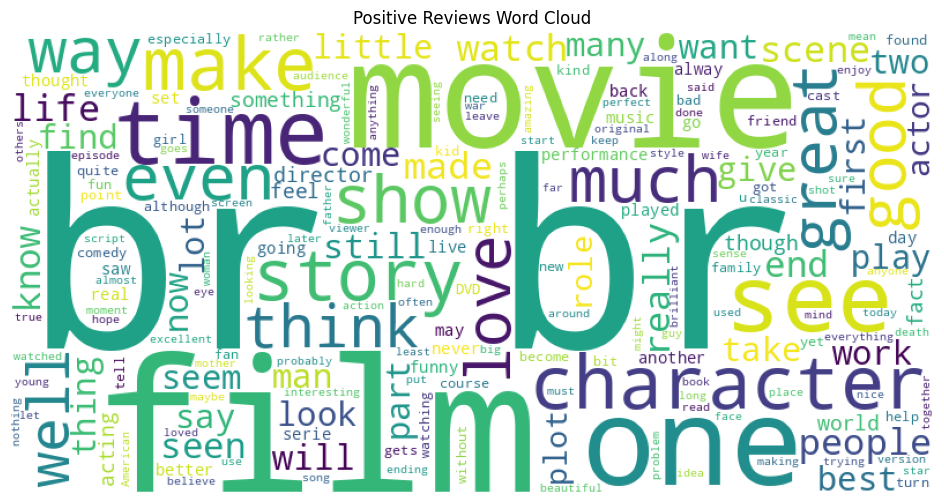

In [42]:
plt.figure(figsize=(12,6))
plt.imshow(WordCloud(width=800, height=400, background_color='white').generate(positive_text))
plt.title('Positive Reviews Word Cloud')
plt.axis('off')

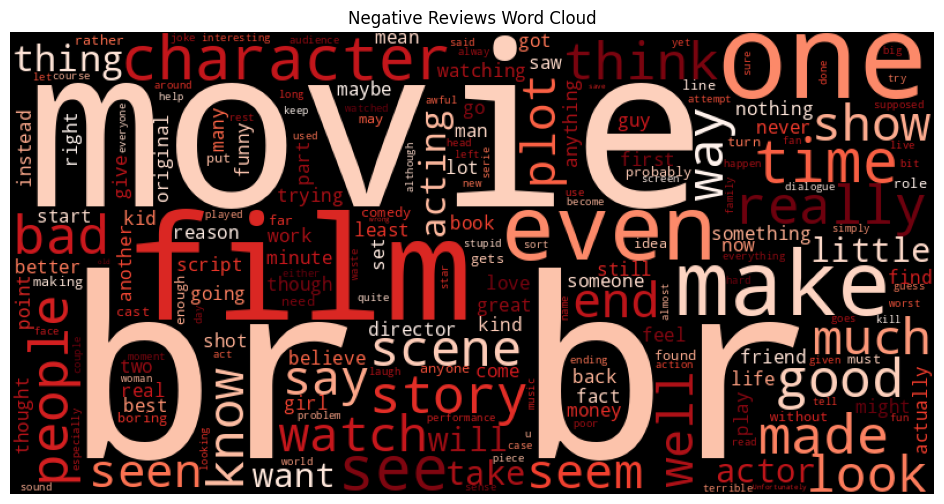

In [43]:
plt.figure(figsize=(12,6))
plt.imshow(WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_text))
plt.title('Negative Reviews Word Cloud')
plt.axis('off')
plt.show()

sentiment
1    25000
0    25000
Name: count, dtype: int64
sentiment
1    50.0
0    50.0
Name: proportion, dtype: float64


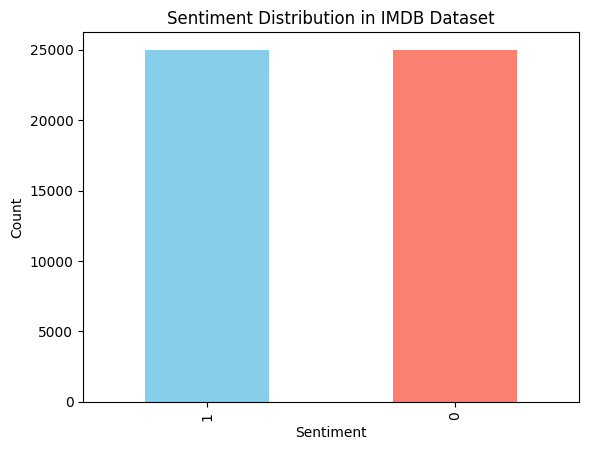

In [9]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)
y.value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Sentiment Distribution in IMDB Dataset")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review, dtype: float64


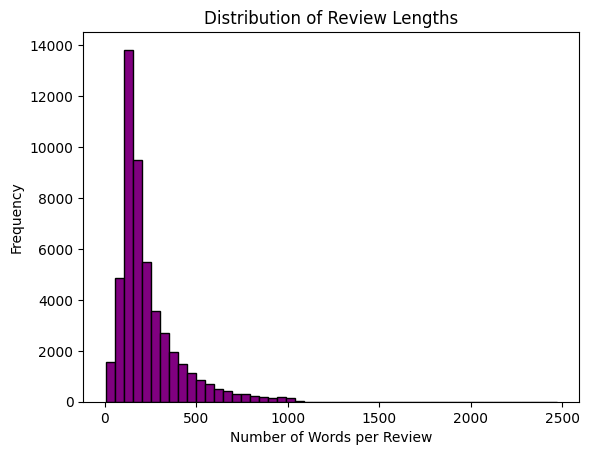

In [10]:
review_lengths = X.apply(lambda x: len(x.split()))
print(review_lengths.describe())  # summary statistics

plt.hist(review_lengths, bins=50, color='purple', edgecolor='black')
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words per Review")
plt.ylabel("Frequency")
plt.show()

In [11]:
from collections import Counter
import re

# Combine all reviews
all_words = " ".join(X).lower()
all_words = re.findall(r'\b\w+\b', all_words)

word_freq = Counter(all_words)
print(word_freq.most_common(20))

[('the', 667993), ('and', 324441), ('a', 322970), ('of', 289410), ('to', 268124), ('is', 211082), ('br', 201951), ('it', 190857), ('in', 186781), ('i', 175633), ('this', 151002), ('that', 143879), ('s', 125008), ('was', 95608), ('as', 91750), ('movie', 87971), ('for', 87471), ('with', 87368), ('but', 83554), ('film', 79705)]


In [ ]:
change_review(y)
print("Value of Y changed")
freqs = build_freqs(y,X)
print("Frequency Built")
update=parameter_X(X,freqs)
print(update)
print("Update Table Built")

In [ ]:
# Write dictionary to a pickle file
with open('data.pkl', 'wb') as pickle_file:
    pickle.dump(freqs, pickle_file)

In [12]:
# Save the frequency dictionary
with open('update.pkl', 'wb') as f:
    pickle.dump(update, f)

Data

In [13]:
from sklearn.model_selection import train_test_split
# Assuming X and y are your features and labels
X_train, X_test, y_train, y_test = train_test_split(update, y, test_size=0.1, random_state=42)

In [14]:
from sklearn.preprocessing import LabelEncoder

# Assuming y_train is your categorical labels in object dtype
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test=label_encoder.fit_transform(y_test)

Model Training

In [21]:
import numpy as np
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense,Bidirectional

In [22]:
results = {}
best_model_name = None
best_model = None
best_accuracy = 0

In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB()
}

In [24]:
t2=time.time()
for name, model in tqdm(models.items(), desc="Training classic models"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name
        best_model = model

t3 = time.time()
print(f"Classic models training time: {t3 - t2:.2f} sec")

Training classic models: 100%|██████████| 3/3 [00:15<00:00,  5.15s/it]

Classic models training time: 15.46 sec


In [25]:
tf_model = keras.Sequential([
    layers.Input(shape=(3,)),   # Three features per sample
    layers.Dense(128, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
tf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
tf_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
loss, acc = tf_model.evaluate(X_test, y_test, verbose=0)
results["TensorFlow NN"] = acc
if acc > best_accuracy:
    best_accuracy = acc
    best_model_name = "TensorFlow NN"
    best_model = tf_model

t4 = time.time()
print(f"TensorFlow model training time: {t4 - t3:.2f} sec")

TensorFlow model training time: 53.65 sec


In [26]:
data = pd.read_csv(r'IMDB_Dataset.csv')
texts = data["review"].astype(str).tolist()  # ensure all reviews are strings
labels = data["sentiment"].map(lambda x: 1 if x == 'positive' else 0).values  # convert to 0/1

vocab_size = 5000
max_len = 200

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

padded = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

from sklearn.model_selection import train_test_split

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    padded, labels, test_size=0.1, random_state=42
)
embedding_dim = 64  # dimension of embedding vector

# --- Simple RNN ---
rnn_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    SimpleRNN(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
t_rnn0 = time.time()
rnn_model.fit(X_train_seq, y_train_seq, epochs=5, batch_size=32, verbose=0)
t_rnn1 = time.time()
rnn_loss, rnn_acc = rnn_model.evaluate(X_test_seq, y_test_seq, verbose=0)
results["RNN"] = rnn_acc
print(f"RNN model accuracy: {rnn_acc:.4f} | Training time: {t_rnn1 - t_rnn0:.2f} sec")

if rnn_acc > best_accuracy:
    best_accuracy = rnn_acc
    best_model_name = "RNN"
    best_model = rnn_model

# --- LSTM ---
lstm_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    LSTM(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
t_lstm0 = time.time()
lstm_model.fit(X_train_seq, y_train_seq, epochs=5, batch_size=32, verbose=0)
t_lstm1 = time.time()
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_seq, y_test_seq, verbose=0)
results["LSTM"] = lstm_acc
print(f"LSTM model accuracy: {lstm_acc:.4f} | Training time: {t_lstm1 - t_lstm0:.2f} sec")

if lstm_acc > best_accuracy:
    best_accuracy = lstm_acc
    best_model_name = "LSTM"
    best_model = lstm_model

# --- Bidirectional LSTM ---
bilstm_model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
bilstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
t_bilstm0 = time.time()
bilstm_model.fit(X_train_seq, y_train_seq, epochs=5, batch_size=32, verbose=0)
t_bilstm1 = time.time()
bilstm_loss, bilstm_acc = bilstm_model.evaluate(X_test_seq, y_test_seq, verbose=0)
results["Bidirectional LSTM"] = bilstm_acc
print(f"Bidirectional LSTM accuracy: {bilstm_acc:.4f} | Training time: {t_bilstm1 - t_bilstm0:.2f} sec")

if bilstm_acc > best_accuracy:
    best_accuracy = bilstm_acc
    best_model_name = "Bidirectional LSTM"
    best_model = bilstm_model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


RNN model accuracy: 0.5260 | Training time: 109.01 sec
LSTM model accuracy: 0.8768 | Training time: 76.44 sec
Bidirectional LSTM accuracy: 0.8768 | Training time: 103.99 sec


In [27]:
results_df = pd.DataFrame([
    {"Model": name, "Accuracy": acc}
    for name, acc in results.items()
])
results_df.sort_values(by="Accuracy", ascending=False, inplace=True)

print("\n📊 Model Accuracy Comparison:")
print(results_df.to_string(index=False))

# Identify best model
best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Accuracy']
print(f"\n🏆 Best Model: {best_model_name} with Accuracy: {best_accuracy:.4f}")

# Save best model
import pickle
if best_model_name not in ["TensorFlow NN", "RNN", "LSTM", "Bidirectional LSTM"]:
    filename = f"best_model_{best_model_name.replace(' ', '_').lower()}.pkl"
    with open(filename, "wb") as f:
        pickle.dump(best_model, f)
else:
    filename = f"best_model_{best_model_name.lower().replace(' ', '_')}.keras"
    best_model.save(filename)

print(f"📁 Saved the best model as '{filename}' with accuracy {best_accuracy:.4f}")

# Save CSV and summary files
results_filename = "model_results.csv"
results_df.to_csv(results_filename, index=False)

summary_filename = "best_model_summary.txt"
with open(summary_filename, "w", encoding="utf-8") as f:
    f.write("📊 Model Accuracy Comparison:\n")
    f.write(results_df.to_string(index=False))
    f.write("\n\n")
    f.write(f"🏆 Best Model: {best_model_name}\n")
    f.write(f"✅ Accuracy: {best_accuracy:.4f}\n")
    f.write(f"📁 Saved as: {filename}\n")

print(f"\n✅ All results saved to:")
print(f"   - {results_filename}")
print(f"   - {summary_filename}")



📊 Model Accuracy Comparison:
              Model  Accuracy
 Bidirectional LSTM    0.8768
               LSTM    0.8768
Logistic Regression    0.6964
      Random Forest    0.6640
                RNN    0.5260
        Naive Bayes    0.5078
      TensorFlow NN    0.4962

🏆 Best Model: Bidirectional LSTM with Accuracy: 0.8768
📁 Saved the best model as 'best_model_bidirectional_lstm.keras' with accuracy 0.8768

✅ All results saved to:
   - model_results.csv
   - best_model_summary.txt


Visualization of Accuracy Of Different Model

/tmp/ipython-input-3061761628.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Accuracy', palette='viridis')


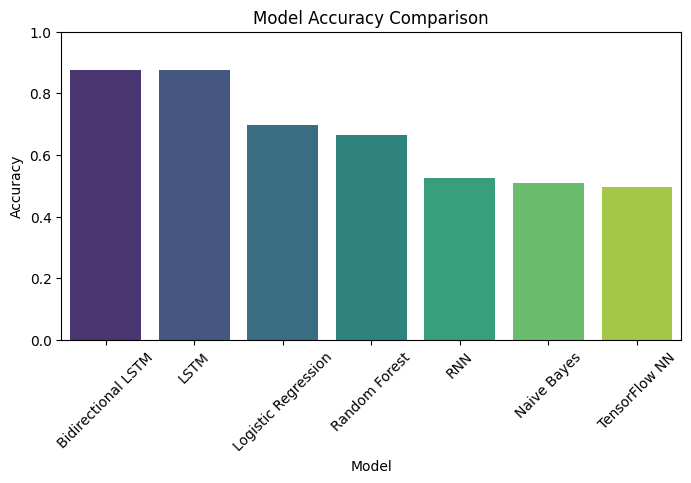

In [40]:
plt.figure(figsize=(8,4))
sns.barplot(data=results_df, x='Model', y='Accuracy', palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.show()

Confusion Matrix

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


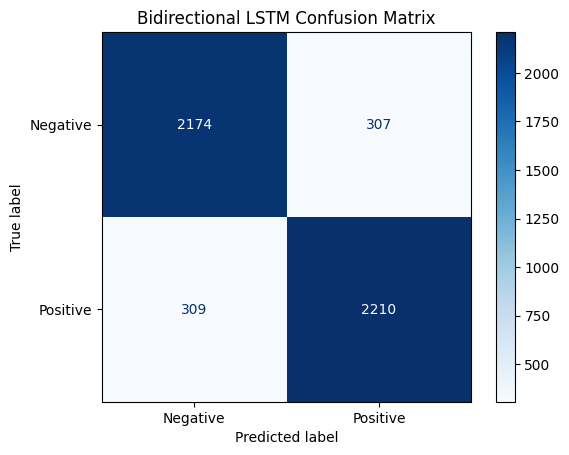

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test_seq if best_model_name in ["RNN","LSTM","Bidirectional LSTM"] else X_test)
if best_model_name in ["RNN","LSTM","Bidirectional LSTM"]:
    y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_test_seq if best_model_name in ["RNN","LSTM","Bidirectional LSTM"] else y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Negative','Positive']).plot(cmap='Blues')
plt.title(f'{best_model_name} Confusion Matrix')
plt.show()
